# Getting started with `chem`

Sanity check that the `chem` kernel and package are wired up correctly.

In [1]:
import chem

chem.__version__

'0.1.0'

## ChEMBL activities for BRAF (UniProt entry name lookup)

`chem.chembl.download_activities` accepts a ChEMBL target id, a UniProt
accession, or a UniProt entry name (mnemonic) such as `BRAF_HUMAN` — it
resolves the id, calls the ChEMBL REST API directly (no
`chembl_webresource_client`), keeps only records with a pChEMBL value,
filters by molecular weight, and (when `normalize_smiles=True`) standardizes
each compound via the ChEMBL Structure Pipeline and aggregates duplicate
compounds into count/mean/median/std.

In [2]:
from chem import chembl

n = chembl.download_activities(
    "BRAF_HUMAN",
    mw=[250, 650],
    normalize_smiles=True,
    output="braf_activities.tsv",
)
n

[16:12:32] Initializing Normalizer
download_activities(id='BRAF_HUMAN', mw=[250, 650], normalize_smiles=True, output='braf_activities.tsv')
braf_activities.tsv already exists, skipping download


5623

### Preview the result

In [3]:
import pandas as pd

df = pd.read_csv("braf_activities.tsv", sep="\t")
print(df.size)
df.sort_values("pchembl_mean", ascending=False).head(10)

44984


,parent_chembl_id,target_chembl_id,smiles,mw,n,pchembl_mean,pchembl_median,pchembl_std
4574,CHEMBL5885861,CHEMBL5145,CCNc1nc(-c2cc(NC(=O)c3cccc(S(C)(=O)=O)c3)ccc2C...,495.61,2,10.70,10.70,0.0
161,CHEMBL500659,CHEMBL5145,Cn1cc(-c2ccc3c(c2)CC/C3=N\O)c(-c2ccncc2)n1,304.35,1,10.70,10.70,0.0
155,CHEMBL498344,CHEMBL5145,O/N=C1\CCc2cc(-c3cn([C@@H]4CCC[C@H](O)C4)nc3-c...,388.47,1,10.40,10.40,0.0
5545,CHEMBL5850574,CHEMBL5145,COc1ccc(S(=O)(=O)NCCCNc2nccc(-c3c(-c4ccc(F)c(O...,554.63,1,10.30,10.30,0.0
151,CHEMBL527029,CHEMBL5145,OCCCn1cc(-c2ccc3c(c2)CC/C3=N\O)c(-c2ccncc2)n1,348.41,1,10.30,10.30,0.0
2227,CHEMBL3651664,CHEMBL5145,CCCS(=O)(=O)Nc1cc(Cl)cc(-c2[nH]c(C(C)(C)C)nc2-...,466.97,1,10.10,10.10,0.0
2245,CHEMBL3651683,CHEMBL5145,CS(=O)(=O)Nc1cc(Cl)cc(-c2[nH]c(C3CC3)nc2-c2ccn...,475.94,1,10.10,10.10,0.0
5551,CHEMBL5982580,CHEMBL5145,COc1ccc(S(=O)(=O)NCCCNc2nccc(-c3c(-c4ccc(F)c(O...,538.56,1,10.10,10.10,0.0
154,CHEMBL521562,CHEMBL5145,O/N=C1\CCc2cc(-c3cn([C@@H]4CCC[C@@H](O)C4)nc3-...,388.47,1,10.05,10.05,0.0
2278,CHEMBL3651613,CHEMBL5145,CCS(=O)(=O)Nc1cc(Cl)cc(-c2[nH]c(C(C)(C)C)nc2-c...,550.09,1,10.00,10.00,0.0


### Draw the top 10 most potent compounds

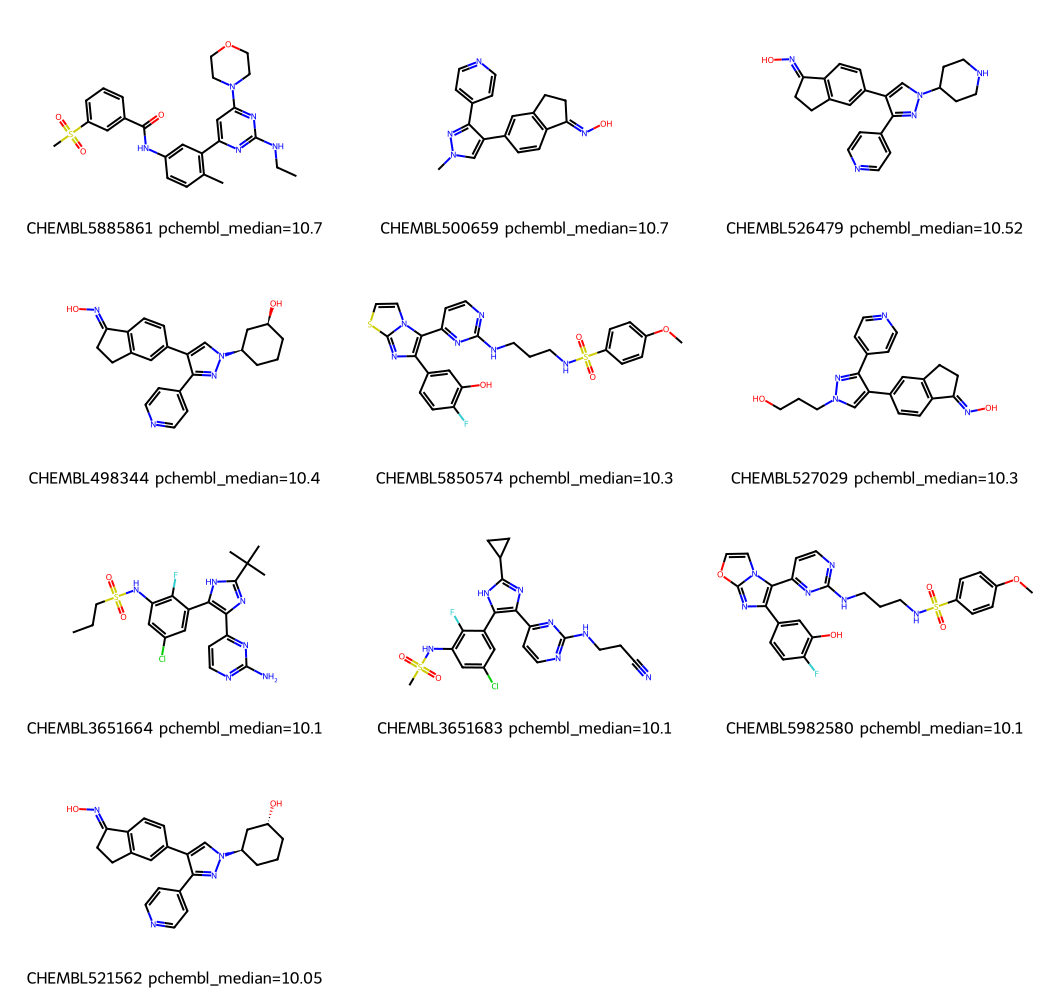

In [4]:
from rdkit import Chem
from rdkit.Chem.Draw import MolsToGridImage

top10 = df.sort_values("pchembl_median", ascending=False).head(10)
mols = [Chem.MolFromSmiles(smi) for smi in top10["smiles"]]
legends = [
    f"{cid} pchembl_median={v}"
    for cid, v in zip(top10["parent_chembl_id"], top10["pchembl_median"])
]
MolsToGridImage(mols, molsPerRow=3, subImgSize=(350, 250), legends=legends)

## RCSB PDB structures for thrombin (UniProt entry name lookup)

`chem.rcsb.download_structures` accepts the same three id forms as
`chem.chembl.download_activities` (ChEMBL target id, UniProt accession, or
UniProt entry name). It resolves the id to a UniProt accession, finds every
PDB entry annotated with that accession via the RCSB Search API, optionally
filters by resolution (entries without one, e.g. NMR structures, are dropped
whenever a threshold is given), and downloads each entry's structure file(s).
Files already present in `outdir` are left alone, so re-running only fetches
what's missing.

In [5]:
from chem import rcsb

n = rcsb.download_structures(
    "THRB_HUMAN",
    resolution_thres=1.5,
    filetype="pdb",
    outdir="data",
)
n

download_structures(id='THRB_HUMAN', resolution_thres=1.5, outdir='data', filetype='pdb')
downloading structures to data: 100%|█████████████████████████████████████████████████████████████████| 66/66 [00:00<00:00, 29136.31entry/s]
wrote 66 structures to data


66

### View one of the downloaded structures

In [6]:
import os

import ipywidgets as widgets
import py3Dmol
from IPython.display import display

from chem.protein import SOLVENT_AND_IONS

pdb_files = sorted(f for f in os.listdir("data") if f.endswith(".pdb"))
print(len(pdb_files), "structures downloaded")

# ".pdb" is common to every option, so show just the 4-character PDB id as the
# button label while keeping the full filename as the underlying value.
picker = widgets.ToggleButtons(
    options=[(os.path.splitext(f)[0], f) for f in pdb_files],
    value=pdb_files[0],
    description="PDB:",
    style={"button_width": "65px"},
    layout=widgets.Layout(width="100%", display="flex", flex_flow="row wrap"),
)
output = widgets.Output()


def render(pdb_filename):
    output.clear_output(wait=True)
    with output:
        path = os.path.join("data", pdb_filename)
        with open(path) as f:
            pdb_text = f.read()

        # Cartoon only draws the polymer backbone, so ligands need an explicit
        # style; skip water/ions/common crystallization additives.
        ligand_resnames = sorted(
            {line[17:20].strip() for line in pdb_text.splitlines() if line.startswith("HETATM")}
            - SOLVENT_AND_IONS
        )

        view = py3Dmol.view(width=600, height=500)
        view.addModel(pdb_text, "pdb")
        # "spectrum" alone defaults to 3Dmol.js's sinebow gradient, whose N-terminal
        # end drifts into purple/magenta; colorscheme="roygb" keeps it to blue (N) ->
        # cyan -> green -> yellow -> orange -> red (C), matching the usual convention.
        view.setStyle({"cartoon": {"color": "spectrum", "colorscheme": "roygb"}})
        if ligand_resnames:
            view.addStyle({"resn": ligand_resnames}, {"stick": {"colorscheme": "yellowCarbon"}})
        view.zoomTo()
        view.show()


picker.observe(lambda change: render(change["new"]) if change["name"] == "value" else None, names="value")
render(picker.value)

display(widgets.VBox([picker, output]))

66 structures downloaded


## AlphaFold DB predicted structure for thrombin (UniProt entry name lookup)

`chem.alphafold.download_structures` accepts the same three id forms as
`chem.chembl.download_activities` and `chem.rcsb.download_structures`. It
resolves the id to a UniProt accession and downloads every AlphaFold DB
prediction entry for it (usually one, but very large proteins may be split
into fragments, and some targets without an official prediction have
community-submitted alternatives instead), optionally filtered by a minimum
average pLDDT confidence (`plddt_thres`, 0-100). As with `chem.rcsb`, files
already present in `outdir` are left alone.

In [7]:
from chem import alphafold

n = alphafold.download_structures(
    "THRB_HUMAN",
    outdir="af_data",
    filetype="pdb",
)
n

download_structures(id='THRB_HUMAN', plddt_thres=None, outdir='af_data', filetype='pdb')
downloading structures to af_data: 100%|█████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 2966.27entry/s]
wrote 1 structures to af_data


1

### View the predicted structure, colored by pLDDT confidence

In [8]:
import os

import py3Dmol

pdb_files = sorted(f for f in os.listdir("af_data") if f.endswith(".pdb"))
print(pdb_files)

with open(os.path.join("af_data", pdb_files[0])) as f:
    view = py3Dmol.view(width=800, height=800)
    view.addModel(f.read(), "pdb")
    # AlphaFold stores per-residue pLDDT confidence in the B-factor column.
    view.setStyle({"cartoon": {"colorscheme": {"prop": "b", "gradient": "roygb", "min": 50, "max": 90}}})
    view.zoomTo()
view.show()

['AF-P00734-F1.pdb']


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Aligning multiple thrombin structures with chem.protein.align

`chem.protein.align` sequence-aligns and structurally superposes a set of
same-target structures (PDB/CIF, RCSB/AlphaFold freely mixed) onto a
reference, selecting each structure's primary polymer chain automatically
(the one with the most standard amino acid residues -- e.g. thrombin's
catalytic heavy chain rather than its short light chain). Here every
downloaded RCSB structure is aligned onto the AlphaFold model (fixed as the
reference, since it doesn't need to be a member of `structures`). It writes
one PDB file per input into `outdir`, so each can be overlaid in the same
viewer.

In [ ]:
import glob
import itertools
import os

import ipywidgets as widgets
import pandas as pd
import py3Dmol
from IPython.display import display

from chem import protein
from chem.protein import SOLVENT_AND_IONS

# Reference is fixed to the AlphaFold model -- not user-selectable.
reference_path = glob.glob("af_data/*.pdb")[0]
reference_id = os.path.splitext(os.path.basename(reference_path))[0]

structures = sorted(glob.glob("data/*.pdb"))
structure_ids = [os.path.splitext(os.path.basename(p))[0] for p in structures]
id_to_path = dict(zip(structure_ids, structures))

# Align every downloaded RCSB structure onto the fixed AlphaFold reference, once.
# align() already returns plain (not numpy) floats rounded to 3dp.
rmsd = protein.align(structures, reference=reference_path, outdir="aligned")
rmsd_df = pd.DataFrame(
    [{"id": os.path.splitext(os.path.basename(p))[0], "rmsd": r} for p, r in rmsd.items()]
).sort_values("rmsd")
display(rmsd_df)

# One independently-toggleable checkbox-style button per structure (unlike
# ToggleButtons, several can be selected at once) for choosing which of the
# already-aligned structures to overlay in the viewer below.
_default_overlay = set(structure_ids[:4])
overlay_toggles = {
    i: widgets.ToggleButton(description=i, value=(i in _default_overlay), layout=widgets.Layout(width="65px"))
    for i in structure_ids
}
overlay_box = widgets.GridBox(
    list(overlay_toggles.values()),
    layout=widgets.Layout(grid_template_columns="repeat(auto-fill, 65px)", width="100%"),
)

output = widgets.Output()
# 3Dmol.js only defines "*Carbon" colorscheme presets for these 8 colors.
_COLORS = ["orange", "cyan", "magenta", "yellow", "green", "purple", "blue", "white"]


def render_overlay(*_):
    output.clear_output(wait=True)
    with output:
        chosen_ids = [i for i, t in overlay_toggles.items() if t.value]
        if not chosen_ids:
            print("Select at least one structure to overlay.")
            return

        view = py3Dmol.view(width=600, height=450)
        # itertools.cycle so the color palette never silently runs out and drops
        # a selected structure, however many are chosen. The (fixed) reference is
        # always shown first.
        for struct_id, color in zip([reference_id] + chosen_ids, itertools.cycle(_COLORS)):
            aligned_path = os.path.join("aligned", f"{struct_id}.pdb")
            with open(aligned_path) as f:
                pdb_text = f.read()
            view.addModel(pdb_text, "pdb")
            view.setStyle({"model": -1}, {"cartoon": {"color": color}})

            # Cartoon only draws the polymer backbone, so ligands need an explicit
            # style; skip water/ions/common crystallization additives.
            ligand_resnames = sorted(
                {line[17:20].strip() for line in pdb_text.splitlines() if line.startswith("HETATM")}
                - SOLVENT_AND_IONS
            )
            if ligand_resnames:
                view.addStyle(
                    {"model": -1, "resn": ligand_resnames}, {"stick": {"colorscheme": f"{color}Carbon"}}
                )
        view.zoomTo()
        view.show()


for _toggle in overlay_toggles.values():
    _toggle.observe(render_overlay, names="value")
render_overlay()

display(widgets.VBox([overlay_box, output]))

### Choose which aligned structures to overlay

The reference is fixed to the AlphaFold model, and every downloaded RCSB
structure is aligned onto it up front (the RMSD table above). Toggle any
number of the resulting structures on to overlay them in the viewer --
independent `ToggleButton`s, so several can be selected at once, updating the
view immediately (no realignment needed, since `aligned/` already has every
structure).

## Finding the ligand pocket with chem.protein.find_pocket

`chem.protein.find_pocket` runs [fpocket](https://github.com/Discngine/fpocket)
on a PDB file and picks the pocket closest to a ligand, returning fpocket's
score/druggability/volume plus the residues lining it.

`4UEH.pdb`'s ligand `BEN` (benzamidine) was tried first, but it's a minimal
fragment that only probes the S1 specificity pocket -- and most of the
highest-resolution structures in this download turn out to be from a
fragment-screening campaign explicitly built around small S1-pocket-only
probes (see `2BVR`'s title), not full active-site-spanning inhibitors.
`3RM0.pdb`'s ligand `S54` (N-(benzylsulfonyl)-D-valyl-N-(4-carbamimidoylbenzyl)-
L-prolinamide -- a real, self-contained, LINK-free designed inhibitor
spanning the S1-S3 subsites) gives a noticeably more complete picture at
comparable resolution (1.34 vs 1.16 A): 27 residues vs 21, and a higher
druggability score (0.874 vs 0.767).

In [10]:
pocket = protein.find_pocket("data/3RM0.pdb", ligand="S54")
print("pocket_id:", pocket["pocket_id"])
print("score:", pocket["score"], "druggability_score:", pocket["druggability_score"])
print("volume:", pocket["volume"])
pocket["residues"]

find_pocket(structure='data/3RM0.pdb', ligand='S54', outdir=None)


pocket_id: 1
score: 0.849 druggability_score: 0.874
volume: 1060.006


selected pocket 1 (score=0.849) near ligand S54 H1: 27 residues


[{'chain': 'H', 'resnum': 60, 'icode': 'A', 'resname': 'TYR'},
 {'chain': 'H', 'resnum': 174, 'icode': '', 'resname': 'ILE'},
 {'chain': 'H', 'resnum': 97, 'icode': 'A', 'resname': 'GLU'},
 {'chain': 'H', 'resnum': 99, 'icode': '', 'resname': 'LEU'},
 {'chain': 'H', 'resnum': 98, 'icode': '', 'resname': 'ASN'},
 {'chain': 'H', 'resnum': 60, 'icode': 'D', 'resname': 'TRP'},
 {'chain': 'H', 'resnum': 60, 'icode': 'F', 'resname': 'LYS'},
 {'chain': 'H', 'resnum': 57, 'icode': '', 'resname': 'HIS'},
 {'chain': 'H', 'resnum': 195, 'icode': '', 'resname': 'SER'},
 {'chain': 'H', 'resnum': 215, 'icode': '', 'resname': 'TRP'},
 {'chain': 'H', 'resnum': 190, 'icode': '', 'resname': 'ALA'},
 {'chain': 'H', 'resnum': 214, 'icode': '', 'resname': 'SER'},
 {'chain': 'H', 'resnum': 191, 'icode': '', 'resname': 'CYS'},
 {'chain': 'H', 'resnum': 216, 'icode': '', 'resname': 'GLY'},
 {'chain': 'H', 'resnum': 219, 'icode': '', 'resname': 'GLY'},
 {'chain': 'H', 'resnum': 189, 'icode': '', 'resname': 'AS

### Consensus active site residues across every aligned structure

Rather than trusting a single structure's pocket, run `find_pocket` on every
aligned RCSB structure that has a usable ligand, and count how often each
residue (by chymotrypsin-numbered `resnum`/`icode`, which is consistent
across thrombin PDB entries) shows up in the detected pocket. Per structure,
the ligand is auto-picked as its largest HETATM group excluding solvent/ions
(`chem.protein.SOLVENT_AND_IONS`) *and* the glycosylation sugar `NAG` /
sulfotyrosine `TYS` common throughout this hirudin-bound dataset, neither of
which is the pharmacological ligand. Structures with no such group (no bound
ligand) are skipped.

In [ ]:
import os

import pandas as pd
from tqdm.notebook import tqdm

from chem.protein import SOLVENT_AND_IONS

# NAG (glycosylation) and TYS (sulfated hirudin-fragment tyrosine) aren't solvent,
# but they aren't the pharmacological ligand either -- exclude them too when
# picking each structure's ligand.
_ligand_exclude = SOLVENT_AND_IONS | {"NAG", "TYS", "MRD"}


def _pick_ligand_code(path):
    """The resname of the largest non-excluded HETATM group in a PDB file, or None."""
    counts = {}
    with open(path) as f:
        for line in f:
            if line.startswith("HETATM"):
                resname = line[17:20].strip()
                if resname in _ligand_exclude:
                    continue
                counts[resname] = counts.get(resname, 0) + 1
    return max(counts, key=counts.get) if counts else None


consensus_counts = {}  # (resnum, icode) -> {"resname": ..., "count": int}
n_analyzed = 0
skipped = []

for struct_id in tqdm(structure_ids, desc="running find_pocket on aligned structures"):
    aligned_path = os.path.join("aligned", f"{struct_id}.pdb")
    ligand_code = _pick_ligand_code(aligned_path)
    if ligand_code is None:
        skipped.append((struct_id, "no non-solvent ligand"))
        continue
    try:
        pocket = protein.find_pocket(aligned_path, ligand=ligand_code)
    except Exception as e:
        skipped.append((struct_id, str(e)))
        continue

    n_analyzed += 1
    for r in pocket["residues"]:
        key = (r["resnum"], r["icode"])
        entry = consensus_counts.setdefault(key, {"resname": r["resname"], "count": 0})
        entry["count"] += 1

print(f"\nanalyzed {n_analyzed} structures, skipped {len(skipped)}:")
for struct_id, reason in skipped:
    print(f"  {struct_id}: {reason}")

running find_pocket on aligned structures:   0%|          | 0/66 [00:00<?, ?it/s]

find_pocket(structure='aligned/1C5N.pdb', ligand='ESI', outdir=None)
selected pocket 1 (score=0.476) near ligand ESI H522: 23 residues
find_pocket(structure='aligned/1H8D.pdb', ligand='PHW', outdir=None)
selected pocket 1 (score=0.962) near ligand PHW H301: 21 residues
find_pocket(structure='aligned/2BVR.pdb', ligand='4CP', outdir=None)
selected pocket 1 (score=0.584) near ligand 4CP H1246: 30 residues
find_pocket(structure='aligned/2BVS.pdb', ligand='2CE', outdir=None)
selected pocket 1 (score=0.78) near ligand 2CE H1246: 29 residues
find_pocket(structure='aligned/2CF8.pdb', ligand='ESH', outdir=None)
selected pocket 1 (score=0.534) near ligand ESH H1246: 34 residues
find_pocket(structure='aligned/2CN0.pdb', ligand='F25', outdir=None)
selected pocket 1 (score=0.805) near ligand F25 H1246: 26 residues
find_pocket(structure='aligned/2UUJ.pdb', ligand='896', outdir=None)
selected pocket 1 (score=0.623) near ligand 896 B1250: 43 residues
find_pocket(structure='aligned/2UUK.pdb', ligand='8

### Residue frequency across structures

In [ ]:
consensus_df = pd.DataFrame(
    [
        {
            "resname": v["resname"],
            "resnum": resnum,
            "icode": icode,
            "count": v["count"],
            "fraction": round(v["count"] / n_analyzed, 3),
        }
        for (resnum, icode), v in consensus_counts.items()
    ]
).sort_values(["fraction", "resnum"], ascending=[False, True])
display(consensus_df)

### Consensus active site: adjustable threshold, structure viewer

`threshold` is the minimum fraction of analyzed structures a residue must
appear in (fpocket's detected pocket) to count as "consensus active site".
Lower it to widen the site (e.g. for MD or vina docking flexible-residue
selection); raise it to tighten to only the most consistently-detected
residues. `consensus_resnums`/`consensus_active_site` (recomputed live as
the slider moves) are the definitive list to export downstream. Pick which
aligned structure to view the result on, including the AlphaFold model --
its `resnum`s differ from the chymotrypsin-numbered RCSB convention the
consensus is computed in (sequential from the UniProt precursor's start,
1-622), so a resnum->resnum lookup is built once via the same
sequence-alignment machinery `chem.protein.align` uses internally,
referenced against `3RM0` (the structure the consensus numbers come from).

In [ ]:
import ipywidgets as widgets
from IPython.display import display

from chem.protein.structural_align import _chain_seq_and_ca, _load_structure, _matched_ca_pairs, _select_chain

# resnum -> resnum lookup from the chymotrypsin-numbered reference (3RM0) to the
# AlphaFold model's own UniProt-sequential numbering, via sequence alignment.
_chymo_structure = _load_structure("aligned/3RM0.pdb")
_chymo_chain = _select_chain(next(_chymo_structure.get_models()))
_chymo_seq, _chymo_ca = _chain_seq_and_ca(_chymo_chain)

_af_structure = _load_structure(os.path.join("aligned", f"{reference_id}.pdb"))
_af_chain = _select_chain(next(_af_structure.get_models()))
_af_seq, _af_ca = _chain_seq_and_ca(_af_chain)

_chymo_pts, _af_pts = _matched_ca_pairs(_chymo_seq, _chymo_ca, _af_seq, _af_ca)
_chymo_to_af_resnum = {
    (a.get_parent().id[1], a.get_parent().id[2].strip()): b.get_parent().id[1]
    for a, b in zip(_chymo_pts, _af_pts)
}

threshold_slider = widgets.FloatSlider(
    value=0.5,
    min=0.1,
    max=1.0,
    step=0.05,
    description="Threshold:",
    readout_format=".2f",
    continuous_update=False,
)
structure_picker = widgets.ToggleButtons(
    options=[(f"{reference_id} (AlphaFold)", reference_id)] + [(i, i) for i in structure_ids],
    value="3RM0",
    description="Structure:",
    style={"button_width": "100px"},
    layout=widgets.Layout(width="100%", display="flex", flex_flow="row wrap"),
)
consensus_output = widgets.Output()

consensus_active_site = None
consensus_resnums = None


def render_consensus(*_):
    global consensus_active_site, consensus_resnums
    consensus_output.clear_output(wait=True)
    with consensus_output:
        consensus_active_site = consensus_df[consensus_df["fraction"] >= threshold_slider.value].sort_values(
            ["resnum", "icode"]
        )
        consensus_resnums = [(r.resnum, r.icode) for r in consensus_active_site.itertuples()]
        labels = [f"{r.resname.capitalize()}{r.resnum}{r.icode}" for r in consensus_active_site.itertuples()]
        print(
            f"{len(labels)} consensus active site residues "
            f"(present in >={threshold_slider.value * 100:.0f}% of {n_analyzed} analyzed structures):"
        )
        print(", ".join(labels))

        struct_id = structure_picker.value
        if struct_id == reference_id:
            resnums = sorted(
                {_chymo_to_af_resnum[key] for key in consensus_resnums if key in _chymo_to_af_resnum}
            )
        else:
            resnums = sorted({resnum for resnum, _icode in consensus_resnums})

        path = os.path.join("aligned", f"{struct_id}.pdb")
        with open(path) as f:
            pdb_text = f.read()

        ligand_resnames = sorted(
            {line[17:20].strip() for line in pdb_text.splitlines() if line.startswith("HETATM")}
            - SOLVENT_AND_IONS
        )

        view = py3Dmol.view(width=600, height=450)
        view.addModel(pdb_text, "pdb")
        # Thin, translucent backbone so the highlighted residues stand out.
        view.setStyle({"cartoon": {"color": "lightgrey", "opacity": 0.25}})
        if resnums:
            view.addStyle({"resi": resnums}, {"stick": {"colorscheme": "greenCarbon"}})
            view.addResLabels(
                {"resi": resnums},
                {
                    "font": "sans-serif",
                    "fontSize": 12,
                    "fontColor": "black",
                    "showBackground": True,
                    "backgroundColor": "white",
                    "backgroundOpacity": 0.7,
                },
            )
        if ligand_resnames:
            view.addStyle({"resn": ligand_resnames}, {"stick": {"colorscheme": "orangeCarbon"}})
        view.zoomTo({"resi": resnums} if resnums else {})
        view.show()


threshold_slider.observe(render_consensus, names="value")
structure_picker.observe(render_consensus, names="value")
render_consensus()

display(widgets.VBox([threshold_slider, structure_picker, consensus_output]))